# Efficient Predator–Prey Paper Analysis
One tensor workflow for every available Couzin/biological expert/imitation case; unavailable cases are skipped cleanly.

The notebook follows the analysis pipeline in execution order: configuration, case preparation, shared metric computation, metric-specific visualizations, and finally the modular-network comparison. Expensive trajectories and derived results are calculated once and then reused.

In [1]:
# Standard-library, numerical, plotting, and notebook-display imports.
from pathlib import Path
import html, math, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import HTML, display

# Resolve project paths whether the notebook starts in the project root or this folder.
ANALYSIS_DIR = Path.cwd().resolve()
if ANALYSIS_DIR.name != 'Paper Analysis': ANALYSIS_DIR = ANALYSIS_DIR / 'Paper Analysis'
PROJECT_ROOT, NICOLE_ROOT = ANALYSIS_DIR.parent, ANALYSIS_DIR.parent / 'Nicole' / 'Predator-Prey-Thesis'
OUTPUT_DIR = ANALYSIS_DIR / 'outputs'

# Import the local analysis helpers without changing either source repository.
if str(ANALYSIS_DIR) not in sys.path: sys.path.insert(0, str(ANALYSIS_DIR))
import paper_analysis as pa

c:\Users\janni\anaconda3\envs\test_gail\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

This section contains the small set of global analysis choices. Thresholds and risk bins are shared across every source, policy, and group size so comparisons use identical definitions.

In [2]:
# Tensor execution settings.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float32

# Validated shared approach and response definitions.
APPROACH_DISTANCE_THRESHOLD, APPROACH_CLOSING_LAG = 0.15, 3
CLOSING_SPEED_LAG = 3
RESPONSE_THRESHOLD, RESPONSE_WINDOW_STEPS = 0.10, 20
RESPONSE_THRESHOLD_SENSITIVITY = (0.075, 0.10, 0.125)
RESPONSE_LAG, TIME_CHUNK_SIZE = 1, 4096

# Source-specific central q01-q99 Expert-Imitation overlap from data_validation.ipynb.
RISK_RANGES = {'couzin':(0.0144023038,0.2365715653),'biological':(0.0307952035,0.3913621008)}
N_DISTANCE_BINS, MIN_SAMPLES_PER_BIN, MIN_CLIPS_PER_BIN = 10, 30, 5
N_BOOTSTRAP, CI_LEVEL = 1000, 0.95
RISK_BIN_EDGES = {source:torch.linspace(low,high,N_DISTANCE_BINS+1,device=DEVICE,dtype=DTYPE) for source,(low,high) in RISK_RANGES.items()}

# Source-specific arena diagonals used for distance normalization.
D_SOURCE = {'couzin': math.hypot(50, 50), 'biological': math.hypot(2160, 2160)}

# Rollout generation and optional result persistence.
N_ROLLOUTS, ROLLOUT_STEPS, SEED, SAVE_RESULTS = 20, 1000, 2027, False
ANALYSIS_SIGNATURE = {'approach_threshold':APPROACH_DISTANCE_THRESHOLD,'approach_lag':APPROACH_CLOSING_LAG,'closing_lag':CLOSING_SPEED_LAG,'response_threshold':RESPONSE_THRESHOLD,'response_threshold_sensitivity':RESPONSE_THRESHOLD_SENSITIVITY,'response_window':RESPONSE_WINDOW_STEPS,'n_bins':N_DISTANCE_BINS,'min_samples':MIN_SAMPLES_PER_BIN,'min_clips':MIN_CLIPS_PER_BIN,'risk_ranges':RISK_RANGES}
print({'device':str(DEVICE),'D_source':D_SOURCE,'risk_ranges':RISK_RANGES})


{'device': 'cuda', 'D_source': {'couzin': 70.71067811865476, 'biological': 3054.7012947258854}, 'risk_ranges': {'couzin': (0.0144023038, 0.2365715653), 'biological': (0.0307952035, 0.3913621008)}}


## Load or generate all cases once
`D_source` is the declared arena diagonal, never an observed trajectory maximum. Nearest prey is recomputed every frame and is only a target proxy.

The workspace currently has no continuous biological 16-prey expert trajectory. That intended case is reported under `skipped_cases` without a warning; init pools and overlapping training windows are deliberately not treated as expert sequences.

In [3]:
# Checkpoint and environment settings for the Couzin-trained policy pair.
COUZIN_POLICY = {
 'root': NICOLE_ROOT, 'code_subdir': '.',
 'prey_checkpoint': 'Data/2. Training/CouzinPredPrey - GAIL/stage1_seed42_32and16/prey_policy_stage1.pth',
 'pred_checkpoint': 'Data/2. Training/CouzinPredPrey - GAIL/stage1_seed42_32and16/pred_policy_stage1.pth',
 'prey_features': 6, 'pred_features': 5, 'deterministic': False,
 'environment': {'area_width':50,'area_height':50,'prey_speed':5,'pred_speed':5,'step_size':0.5,'max_turn':0.25,'max_speed_norm':5.0}}

# Checkpoint and environment settings for the biologically trained policy pair.
BIO_POLICY = {
 'root': NICOLE_ROOT, 'code_subdir': '.',
 'prey_checkpoint': 'Data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16/prey_policy_stage1.pth',
 'pred_checkpoint': 'Data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16/pred_policy_stage1.pth',
 'prey_features': 6, 'pred_features': 5, 'deterministic': False,
 'environment': {'area_width':2160,'area_height':2160,'prey_speed':10,'pred_speed':10,'step_size':1.0,'max_turn':0.314,'max_speed_norm':25.0}}

# Existing expert-trajectory and initialization-pool locations.
BIO_EXPERT_ROOTS = {n: NICOLE_ROOT / f'Data/1. Data Processing/Processed/video/expert_tensors/{n}_prey_interactions/2. filtered_frames' for n in (16,32)}
INIT_POOLS = {n: NICOLE_ROOT / f'Data/1. Data Processing/Processed/init_pool/init_pool_{n}prey.pt' for n in (16,32)}

# Declare all intended source × policy type × group-size combinations in one place.
case_specs = {
 **{f'couzin_expert_{n}': {'source':'couzin','kind':'couzin_expert','n_prey':n} for n in (16,32)},
 **{f'couzin_imitation_{n}': {'source':'couzin','kind':'imitation','n_prey':n,'policy':COUZIN_POLICY} for n in (16,32)},
 **{f'bio_expert_{n}': {'source':'biological','kind':'bio_expert','n_prey':n} for n in (16,32)},
 **{f'bio_imitation_{n}': {'source':'biological','kind':'imitation','n_prey':n,'policy':BIO_POLICY} for n in (16,32)}}

# Load expert data or generate imitation rollouts exactly once per case.
cases, skipped_cases, case_diagnostics = {}, {}, {}
for offset, (name, spec) in enumerate(tqdm(case_specs.items(), desc='Loading/generating cases')):
 n = spec['n_prey']
 if spec['kind'] == 'bio_expert' and not BIO_EXPERT_ROOTS[n].is_dir():
  skipped_cases[name] = 'No continuous expert trajectory is present (init pools/windows are not valid substitutes).'
  continue
 try:
  if spec['kind'] == 'couzin_expert':
   table = pa.generate_couzin_expert_rollouts(NICOLE_ROOT,n_prey=n,n_rollouts=N_ROLLOUTS,rollout_steps=ROLLOUT_STEPS,seed=SEED+offset)
  elif spec['kind'] == 'bio_expert':
   table = pa.load_expert_trajectories(BIO_EXPERT_ROOTS[n],n_prey=n,condition='all',image_y_down=True,coordinate_height=2160,role_map={'1':'predator','2':'prey'},require_complete_frames=True)
  else:
   config = spec['policy']; init_pool = None if spec['source'] == 'couzin' else INIT_POOLS[n]
   table = pa.generate_policy_rollouts(config,config['root'],n_prey=n,n_rollouts=N_ROLLOUTS,rollout_steps=ROLLOUT_STEPS,seed=SEED+offset,init_pool_path=init_pool)
 except (FileNotFoundError, pa.ExpertDataUnavailable) as exc:
  skipped_cases[name] = str(exc)
  continue

 # Validate every loaded case before it enters the shared analysis workflow.
 diag = pa.trajectory_diagnostics(table)
 if diag['prey_per_frame_min'] != n or diag['prey_per_frame_max'] != n:
  raise ValueError(f'{name}: expected exactly {n} prey in every frame, got {diag}')
 if not np.all(np.isfinite(table['x'])) or not np.all(np.isfinite(table['y'])) or not np.all(np.isfinite(table['heading'])):
  raise ValueError(f'{name}: non-finite position or heading detected')
 cases[name], case_diagnostics[name] = table, diag

# Show one concise availability overview and the diagnostics of usable cases.
display({'available_cases': sorted(cases), 'skipped_cases': skipped_cases})
display(case_diagnostics)


Loading/generating cases: 100%|██████████| 8/8 [11:48<00:00, 88.61s/it] 


{'available_cases': ['bio_expert_32',
  'bio_imitation_16',
  'bio_imitation_32',
  'couzin_expert_16',
  'couzin_expert_32',
  'couzin_imitation_16',
  'couzin_imitation_32'],
 'skipped_cases': {'bio_expert_16': 'No continuous expert trajectory is present (init pools/windows are not valid substitutes).'}}

{'couzin_expert_16': {'rows': 340000,
  'clips_or_rollouts': 20,
  'frames': 20000,
  'prey_per_frame_min': 16,
  'prey_per_frame_max': 16,
  'x_range': (-2.4999999890285083, 52.49991394902054),
  'y_range': (-2.4999871195112235, 52.49996006229406),
  'heading_range': (-3.141582229434665, 3.141584526483916),
  'conditions': {np.str_('approach'): 340000},
  'fps_values': [],
  'timestep_status': 'PHYSICAL TIME UNKNOWN'},
 'couzin_expert_32': {'rows': 660000,
  'clips_or_rollouts': 20,
  'frames': 20000,
  'prey_per_frame_min': 32,
  'prey_per_frame_max': 32,
  'x_range': (-2.499974720310492, 52.49998754799828),
  'y_range': (-2.4999779197080216, 52.499825518459616),
  'heading_range': (-3.1415718584578896, 3.1415784160929654),
  'conditions': {np.str_('approach'): 660000},
  'fps_values': [],
  'timestep_status': 'PHYSICAL TIME UNKNOWN'},
 'couzin_imitation_16': {'rows': 340000,
  'clips_or_rollouts': 20,
  'frames': 20000,
  'prey_per_frame_min': 16,
  'prey_per_frame_max': 16,
  'x_ra

In [4]:
# Run the complete metric suite once for every available case.
case_results = {}
with torch.inference_mode():
 for name, table in tqdm(cases.items(), desc='Analyzing cases'):
  source = case_specs[name]['source']
  case_results[name] = pa.analyze_case(table,d_source=D_SOURCE[source],risk_bin_edges=RISK_BIN_EDGES[source],expected_n_prey=case_specs[name]['n_prey'],device=DEVICE,dtype=DTYPE,time_chunk_size=TIME_CHUNK_SIZE,approach_distance_threshold=APPROACH_DISTANCE_THRESHOLD,approach_closing_lag=APPROACH_CLOSING_LAG,closing_speed_lag=CLOSING_SPEED_LAG,response_threshold=RESPONSE_THRESHOLD,response_threshold_sensitivity=RESPONSE_THRESHOLD_SENSITIVITY,response_window_steps=RESPONSE_WINDOW_STEPS,response_lag=RESPONSE_LAG,min_bin_count=MIN_SAMPLES_PER_BIN,min_cluster_count=MIN_CLIPS_PER_BIN,n_bootstrap=N_BOOTSTRAP,ci_level=CI_LEVEL,bootstrap_seed=SEED)

# Calculate explicit 16-to-32 changes wherever a complete quartet exists.
group_size_results = pa.compute_all_group_size_comparisons(case_results)

# Build a metric-first view for later figure construction and serialization.
results = {}
for metric in ('closing_speed','pursuit_alignment','escape_alignment','risk_conditioned_nnd','risk_conditioned_polarization','continuous_predator_response_curve'):
 results[metric] = {name:r['curves'][metric] for name,r in case_results.items()}
for metric in next(iter(case_results.values()))['aggregate'] if case_results else ():
 results.setdefault(metric,{}).update({name:r['aggregate'][metric] for name,r in case_results.items()})
results['events'] = {name:r['events'] for name,r in case_results.items()}
results['response_availability'] = {name:r['response_availability'] for name,r in case_results.items()}
results['predator_distance_raw'] = {name:r['predator_distance_raw'] for name,r in case_results.items()}
results['predator_distance_normalized'] = {name:r['predator_distance_normalized'] for name,r in case_results.items()}
results['diagnostics'] = {name:r['diagnostics'] for name,r in case_results.items()}
results['response_threshold_sensitivity'] = {name:r['response_threshold_sensitivity'] for name,r in case_results.items()}
results['group_size'] = group_size_results
results['analysis_signature'] = ANALYSIS_SIGNATURE

# Concise segmentation and event-consistency diagnostics.
segmentation_rows=[{'case':name,**r['diagnostics']} for name,r in case_results.items()]
display(segmentation_rows)

# Lightweight consistency check against the compact data-validation cache.
validation_cache_path=OUTPUT_DIR/'data_validation_derived.pt'; validation_consistency=[]
if validation_cache_path.is_file():
 try: validation_cache=torch.load(validation_cache_path,map_location='cpu',weights_only=False)
 except TypeError: validation_cache=torch.load(validation_cache_path,map_location='cpu')
 for name,r in case_results.items():
  if name not in validation_cache.get('derived',{}): continue
  cached=validation_cache['derived'][name]; expected_approaches=0; expected_responding=0
  for segment in cached['distance_segments']:
   expected_approaches += len(pa.detect_approach_events(segment['d_norm'],threshold=APPROACH_DISTANCE_THRESHOLD,closing_lag=APPROACH_CLOSING_LAG))
  for segment in cached['response_segments']:
   onsets=pa.detect_approach_events(segment['d_norm'],threshold=APPROACH_DISTANCE_THRESHOLD,closing_lag=APPROACH_CLOSING_LAG)
   for onset in onsets.tolist():
    stop=min(onset+RESPONSE_WINDOW_STEPS+1,len(segment['response']))
    expected_responding += int(onset<stop and bool((segment['response'][onset:stop]>RESPONSE_THRESHOLD).any()))
  expected={'valid_frames':validation_cache['coverage'][name]['valid_predator_prey_frames'],'temporal_segments':len(cached['distance_segments']),'response_capable_segments':len(cached['response_segments']),'approach_events':expected_approaches,'responding_events':expected_responding}
  observed=r['diagnostics']; validation_consistency.append({'case':name,**{f'validation_{k}':v for k,v in expected.items()},**{f'analysis_{k}':observed[k] for k in expected},'all_match':all(observed[k]==v for k,v in expected.items())})
 display(validation_consistency)

# Saving is optional because all results remain available in memory.
if SAVE_RESULTS:
 OUTPUT_DIR.mkdir(parents=True,exist_ok=True); torch.save(results,OUTPUT_DIR/'predator_prey_metrics.pt')


Analyzing cases: 100%|██████████| 7/7 [00:36<00:00,  5.23s/it]


[{'case': 'couzin_expert_16',
  'valid_frames': 20000,
  'invalid_frames': 0,
  'frame_clips': 20,
  'frame_level_segments': 20,
  'temporal_segments': 20,
  'response_segments': 20,
  'response_capable_segments': 20,
  'approach_events': 911,
  'response_approach_events': 911,
  'responding_events': 909,
  'total_approach_events': 911,
  'valid_propagation_events': 909,
  'fraction_valid_propagation_events': 0.9978046103183315},
 {'case': 'couzin_expert_32',
  'valid_frames': 20000,
  'invalid_frames': 0,
  'frame_clips': 20,
  'frame_level_segments': 20,
  'temporal_segments': 20,
  'response_segments': 20,
  'response_capable_segments': 20,
  'approach_events': 1117,
  'response_approach_events': 1117,
  'responding_events': 1117,
  'total_approach_events': 1117,
  'valid_propagation_events': 1117,
  'fraction_valid_propagation_events': 1.0},
 {'case': 'couzin_imitation_16',
  'valid_frames': 20000,
  'invalid_frames': 0,
  'frame_clips': 20,
  'frame_level_segments': 20,
  'tempora

[{'case': 'couzin_expert_16',
  'validation_valid_frames': 20000,
  'validation_temporal_segments': 20,
  'validation_response_capable_segments': 20,
  'validation_approach_events': 911,
  'validation_responding_events': 909,
  'analysis_valid_frames': 20000,
  'analysis_temporal_segments': 20,
  'analysis_response_capable_segments': 20,
  'analysis_approach_events': 911,
  'analysis_responding_events': 909,
  'all_match': True},
 {'case': 'couzin_expert_32',
  'validation_valid_frames': 20000,
  'validation_temporal_segments': 20,
  'validation_response_capable_segments': 20,
  'validation_approach_events': 1117,
  'validation_responding_events': 1117,
  'analysis_valid_frames': 20000,
  'analysis_temporal_segments': 20,
  'analysis_response_capable_segments': 20,
  'analysis_approach_events': 1117,
  'analysis_responding_events': 1117,
  'all_match': True},
 {'case': 'couzin_imitation_16',
  'validation_valid_frames': 20000,
  'validation_temporal_segments': 20,
  'validation_respons

In [5]:
# Shared visual language: source panels, expert/imitation colors, and group-size shades.
COLORS={'expert_16':'#1f77b4','expert_32':'#0b3c6f','imitation_16':'#ff8c42','imitation_32':'#c44e00'}
def _style(name):
 return ('couzin' if name.startswith('couzin') else 'biological'), next(x for x in COLORS if x in name)

# Two-panel helper for all risk-conditioned curve metrics.
def plot_curve(metric,ylabel,xlabel='Normalized predator-to-nearest-prey distance'):
 fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
 for ax,source in zip(axes,('couzin','biological')):
  for name,r in case_results.items():
   src,style=_style(name)
   if src!=source: continue
   c=r['curves'][metric]; x,y=c['bin_center'].cpu(),c['mean'].cpu(); ax.plot(x,y,marker='o',ms=3,color=COLORS[style],label=style.replace('_',' ').title()); ax.fill_between(x,c['ci_low'].cpu(),c['ci_high'].cpu(),color=COLORS[style],alpha=.15)
  ax.set(title=source.title(),xlabel=xlabel,ylabel=ylabel,xlim=RISK_RANGES[source]); ax.grid(alpha=.25); handles,labels=ax.get_legend_handles_labels(); ax.legend(handles,labels,frameon=False) if handles else None
 fig.tight_layout(); plt.show()

# Distribution helper for per-clip scalars or per-event observations.
def plot_scalar(metric,ylabel,event=False):
 names,data=[],[]
 for name,r in case_results.items():
  v=r['events'].get(metric) if event else r['per_clip'].get(metric)
  if v is not None and v.numel(): names.append(name.replace('_','\n')); data.append(v.cpu().numpy())
 if data:
  fig,ax=plt.subplots(figsize=(max(8,1.2*len(data)),4)); ax.boxplot(data,tick_labels=names,showfliers=False); ax.set_ylabel(ylabel); ax.grid(axis='y',alpha=.25); fig.tight_layout(); plt.show()

# Event-relative helper for NND and polarization changes after approach onset.
def plot_event(key,ylabel):
 fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
 for ax,source in zip(axes,('couzin','biological')):
  for name,r in case_results.items():
   src,style=_style(name); valid=[x for x in r[key] if x.numel()]
   if src==source and valid:
    v=torch.cat(valid).cpu(); ax.plot(torch.arange(v.shape[1]),torch.nanmean(v,0),color=COLORS[style],label=style.replace('_',' ').title())
  ax.axhline(0,color='.4',lw=.8); ax.set(title=source.title(),xlabel='Steps since approach onset',ylabel=ylabel); ax.grid(alpha=.25); handles,labels=ax.get_legend_handles_labels(); ax.legend(handles,labels,frameon=False) if handles else None
 fig.tight_layout(); plt.show()

# Whole-sequence helper for DoS and DoA time evolution.
def plot_timeline(key,ylabel):
 fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
 for ax,source in zip(axes,('couzin','biological')):
  for name,r in case_results.items():
   src,style=_style(name); series=r[key]; length=max((len(x) for x in series),default=0)
   if src==source and length:
    padded=torch.full((len(series),length),torch.nan,device=series[0].device,dtype=series[0].dtype)
    for i,x in enumerate(series): padded[i,:len(x)]=x
    ax.plot(torch.nanmean(padded,0).cpu(),color=COLORS[style],label=style.replace('_',' ').title())
  ax.set(title=source.title(),xlabel='Source step',ylabel=ylabel); ax.grid(alpha=.25); handles,labels=ax.get_legend_handles_labels(); ax.legend(handles,labels,frameon=False) if handles else None
 fig.tight_layout(); plt.show()

# Numerical outputs mirror every plot and remain available for later use.
numerical_outputs = {}

# Lightweight HTML-table formatting avoids a separate pandas pipeline.
def _format_table_value(value):
 if torch.is_tensor(value) and value.numel()==1: value=value.item()
 if isinstance(value,(float,np.floating)):
  return 'NaN' if not np.isfinite(value) else f'{value:.8g}'
 return str(value)
def display_table(rows,title,max_height=420):
 if not rows:
  display(HTML(f'<h4>{html.escape(title)}</h4><em>No valid values.</em>')); return
 columns=list(rows[0]); head=''.join(f'<th>{html.escape(str(c))}</th>' for c in columns)
 body=''.join('<tr>'+''.join(f'<td>{html.escape(_format_table_value(row.get(c,"")))}</td>' for c in columns)+'</tr>' for row in rows)
 style='border-collapse:collapse;width:100%;font-size:12px;text-align:right'
 display(HTML(f'<style>.metric-table th,.metric-table td{{padding:5px 9px;border-bottom:1px solid #eee;white-space:nowrap}}.metric-table th{{text-align:right}}</style><h4>{html.escape(title)}</h4><div style="max-height:{max_height}px;overflow:auto;border:1px solid #ddd"><table class="metric-table" style="{style}"><thead style="position:sticky;top:0;background:white"><tr>{head}</tr></thead><tbody>{body}</tbody></table></div>'))

# Table builders for curves, distributions, event profiles, and timelines.
def show_curve_values(metric):
 out,rows={},[]
 for name,r in case_results.items():
  c={k:r['curves'][metric][k].detach().cpu().tolist() for k in ('bin_center','mean','ci_low','ci_high','count','cluster_count','supported')}; out[name]=c
  rows.extend({'case':name,'bin':i,'distance':c['bin_center'][i],'mean':c['mean'][i],'ci_low':c['ci_low'][i],'ci_high':c['ci_high'][i],'n':c['count'][i],'clusters':c['cluster_count'][i],'supported':c['supported'][i]} for i in range(len(c['bin_center'])))
 numerical_outputs[metric]=out; display_table(rows,f'{metric}: risk-conditioned values'); return out
def show_distribution_values(metric,event=False):
 full,summary,rows={},{},[]
 for name,r in case_results.items():
  v=r['events'].get(metric) if event else r['per_clip'].get(metric)
  if v is None: continue
  v=v.detach().float().cpu(); v=v[torch.isfinite(v)]; full[name]=v
  valid_clips=int(torch.isfinite(r['per_clip'][metric]).sum()) if metric in r['per_clip'] else np.nan
  s={'case':name,'n':len(v),'valid_clips':valid_clips,'mean':float(v.mean()) if len(v) else np.nan,'std':float(v.std(unbiased=False)) if len(v) else np.nan,'median':float(v.median()) if len(v) else np.nan,'q25':float(torch.quantile(v,.25)) if len(v) else np.nan,'q75':float(torch.quantile(v,.75)) if len(v) else np.nan,'min':float(v.min()) if len(v) else np.nan,'max':float(v.max()) if len(v) else np.nan}; summary[name]={k:x for k,x in s.items() if k!='case'}; rows.append(s)
 numerical_outputs[metric]={'summary':summary,'values':full}; display_table(rows,f'{metric}: numerical summary'); return summary
def show_event_profile_values(key):
 out,rows={},[]
 for name,r in case_results.items():
  valid=[x.detach().cpu() for x in r[key] if x.numel()]
  if not valid: continue
  v=torch.cat(valid); mean=torch.nanmean(v,0); std=torch.nanmean((v-mean)**2,0).sqrt(); count=torch.isfinite(v).sum(0); out[name]={'step':list(range(v.shape[1])),'mean':mean.tolist(),'std':std.tolist(),'count':count.tolist()}
  rows.extend({'case':name,'step':step,'mean':mean[step].item(),'std':std[step].item(),'n':count[step].item()} for step in range(v.shape[1]))
 numerical_outputs[key]=out; display_table(rows,f'{key}: event-relative values'); return out
def show_timeline_values(key,aggregate_metric):
 full,summary,summary_rows,timeline_rows={},{},[],[]
 for name,r in case_results.items():
  length=max((len(x) for x in r[key]),default=0)
  if not length: continue
  timeline=torch.full((len(r[key]),length),torch.nan,device=r[key][0].device,dtype=r[key][0].dtype)
  for i,x in enumerate(r[key]): timeline[i,:len(x)]=x
  timeline=timeline.detach().cpu(); mean_timeline=torch.nanmean(timeline,0); timeline_count=torch.isfinite(timeline).sum(0); aggregate=r['per_clip'][aggregate_metric].detach().cpu(); full[name]={'mean_timeline':mean_timeline,'timeline_count':timeline_count,'per_clip_aggregate':aggregate}
  s={'case':name,'steps':length,'clips':len(timeline),'aggregate_mean':float(aggregate.mean()),'aggregate_std':float(aggregate.std(unbiased=False))}; summary[name]={k:x for k,x in s.items() if k!='case'}; summary_rows.append(s)
  timeline_rows.extend({'case':name,'step':step,'mean':mean_timeline[step].item(),'clips':timeline_count[step].item()} for step in range(length))
 numerical_outputs[aggregate_metric]={'summary':summary,'values':full}; display_table(summary_rows,f'{aggregate_metric}: aggregate values'); display_table(timeline_rows,f'{aggregate_metric}: mean time evolution'); return summary


# Predator Response Metrics

These metrics describe how the predator is positioned and oriented relative to the nearest-prey proxy. Distance and the primary three-step closing speed are normalized by the source-specific arena diagonal, so source families remain comparable.

Each plot is followed by its corresponding numerical table.

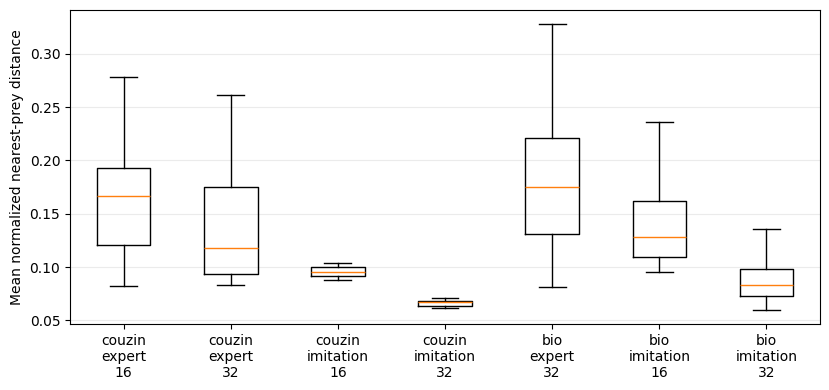

case,n,valid_clips,mean,std,median,q25,q75,min,max
couzin_expert_16,20,20,0.16927086,0.06004028,0.15845454,0.12026564,0.19303232,0.082214691,0.27785608
couzin_expert_32,20,20,0.13816746,0.050556239,0.11503899,0.093781695,0.17546116,0.082867466,0.26127252
couzin_imitation_16,20,20,0.095549926,0.004326262,0.095384166,0.091747388,0.099717602,0.088289343,0.10370032
couzin_imitation_32,20,20,0.066256359,0.0027027994,0.066777654,0.063353352,0.068083972,0.061985016,0.071089052
bio_expert_32,35,35,0.18842006,0.084892377,0.17478029,0.13105966,0.22073635,0.081719026,0.49686906
bio_imitation_16,20,20,0.13868658,0.035551239,0.12710674,0.10907941,0.16185811,0.095647499,0.23629048
bio_imitation_32,20,20,0.089921258,0.023182079,0.082891762,0.073184609,0.098483056,0.060084488,0.14280613


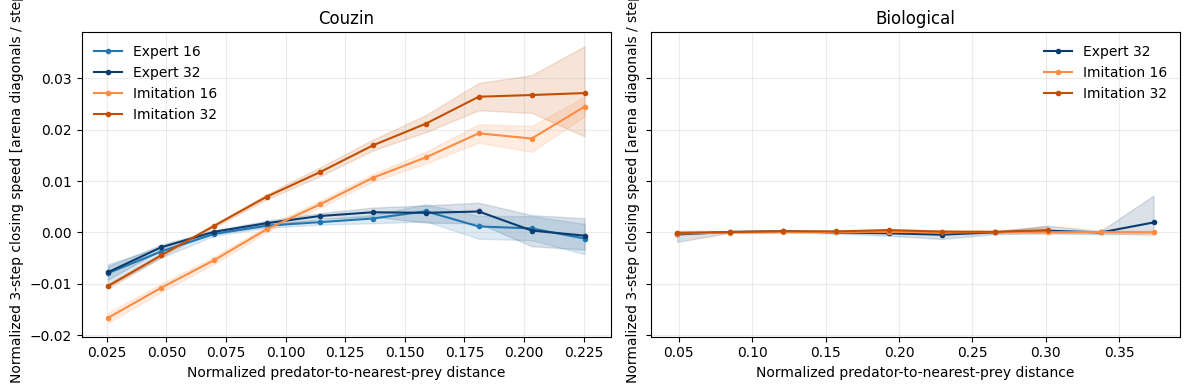

case,bin,distance,mean,ci_low,ci_high,n,clusters,supported
couzin_expert_16,0,0.025510767,-0.0079029687,-0.01043865,-0.006154404,1344,20,True
couzin_expert_16,1,0.047727697,-0.0037221031,-0.0049422556,-0.0028800068,2335,20,True
couzin_expert_16,2,0.06994462,-0.00029076537,-0.00064703904,-1.3418136e-05,3507,20,True
couzin_expert_16,3,0.092161551,0.0013186752,0.00089782442,0.0016905582,2373,20,True
couzin_expert_16,4,0.11437847,0.0020066674,0.0015327566,0.0024660924,1923,20,True
couzin_expert_16,5,0.1365954,0.0027148772,0.0017857101,0.00341209,1189,20,True
couzin_expert_16,6,0.15881231,0.0041257092,0.0021494355,0.0054896134,602,20,True
couzin_expert_16,7,0.18102926,0.001165029,-0.0012241488,0.0032203065,443,20,True
couzin_expert_16,8,0.20324618,0.0007879007,-0.0015059828,0.0031744957,405,20,True
couzin_expert_16,9,0.22546309,-0.0011911532,-0.0042423201,0.0016658003,265,20,True


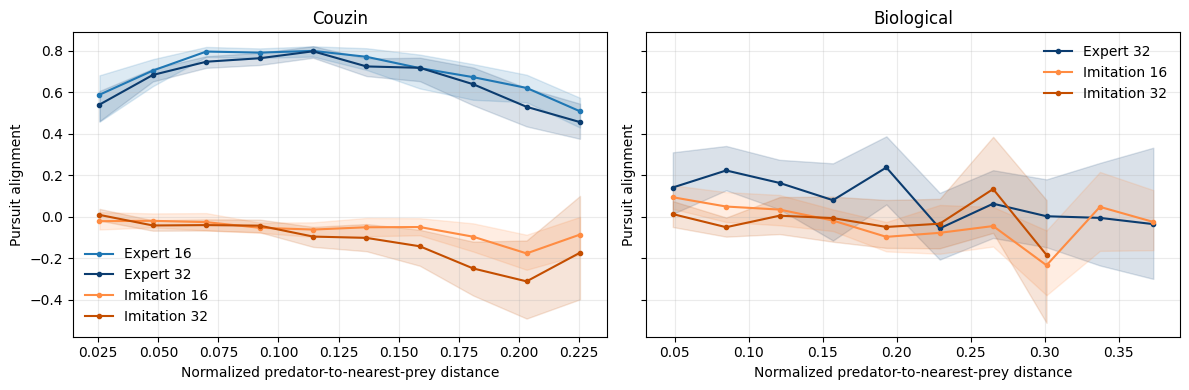

case,bin,distance,mean,ci_low,ci_high,n,clusters,supported
couzin_expert_16,0,0.025510767,0.58886904,0.45869315,0.68252838,1354,20,True
couzin_expert_16,1,0.047727697,0.70550525,0.63012415,0.76031661,2337,20,True
couzin_expert_16,2,0.06994462,0.79722661,0.77146661,0.8194558,3516,20,True
couzin_expert_16,3,0.092161551,0.79209507,0.76642418,0.81230617,2377,20,True
couzin_expert_16,4,0.11437847,0.80038863,0.77294272,0.82238299,1924,20,True
couzin_expert_16,5,0.1365954,0.77189976,0.70856184,0.8133173,1191,20,True
couzin_expert_16,6,0.15881231,0.71727139,0.61921293,0.78250855,606,20,True
couzin_expert_16,7,0.18102926,0.67363286,0.56442207,0.73648697,445,20,True
couzin_expert_16,8,0.20324618,0.62168837,0.5525341,0.68529993,406,20,True
couzin_expert_16,9,0.22546309,0.50899196,0.43061039,0.57422876,265,20,True


{'couzin_expert_16': {'bin_center': [0.025510767474770546,
   0.04772769659757614,
   0.06994462013244629,
   0.09216155111789703,
   0.11437846720218658,
   0.13659539818763733,
   0.15881231427192688,
   0.18102926015853882,
   0.20324617624282837,
   0.22546309232711792],
  'mean': [0.588869035243988,
   0.7055052518844604,
   0.79722660779953,
   0.7920950651168823,
   0.8003886342048645,
   0.7718997597694397,
   0.7172713875770569,
   0.6736328601837158,
   0.6216883659362793,
   0.5089919567108154],
  'ci_low': [0.45869314670562744,
   0.6301241517066956,
   0.7714666128158569,
   0.7664241790771484,
   0.7729427218437195,
   0.7085618376731873,
   0.6192129254341125,
   0.564422070980072,
   0.5525341033935547,
   0.43061038851737976],
  'ci_high': [0.6825283765792847,
   0.7603166103363037,
   0.8194558024406433,
   0.8123061656951904,
   0.8223829865455627,
   0.8133172988891602,
   0.7825085520744324,
   0.7364869713783264,
   0.6852999329566956,
   0.5742287635803223],
  'c

In [6]:
# Overall normalized proximity to the nearest-prey proxy.
plot_scalar('predator_distance','Mean normalized nearest-prey distance'); show_distribution_values('predator_distance')

# Distance change and heading alignment conditioned on the common risk axis.
plot_curve('closing_speed','Normalized 3-step closing speed [arena diagonals / step]'); show_curve_values('closing_speed')
plot_curve('pursuit_alignment','Pursuit alignment'); show_curve_values('pursuit_alignment')


# Prey Response Metrics

Continuous response fixes the predator-away direction at *t*. Valid responses satisfy `R > 0.10` within the next 20 available steps; latency is in source steps, and truncated windows are represented explicitly by availability masks rather than silently dropped.

Escape alignment describes the instantaneous direction of motion. Reaction latency and normalized reaction distance include only responders, while response fraction reports how much of the group responded; the compact sensitivity table checks thresholds 0.075, 0.10, and 0.125.

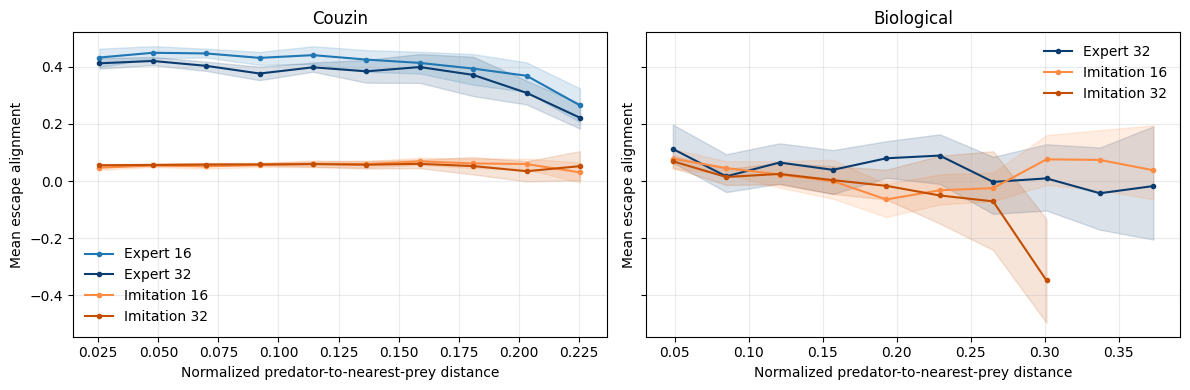

case,bin,distance,mean,ci_low,ci_high,n,clusters,supported
couzin_expert_16,0,0.025510767,0.4323552,0.39893964,0.46339345,1354,20,True
couzin_expert_16,1,0.047727697,0.44889364,0.42953598,0.47203201,2337,20,True
couzin_expert_16,2,0.06994462,0.44657552,0.43248314,0.46334562,3516,20,True
couzin_expert_16,3,0.092161551,0.43108565,0.40642807,0.45172045,2377,20,True
couzin_expert_16,4,0.11437847,0.44064033,0.40924504,0.47179627,1924,20,True
couzin_expert_16,5,0.1365954,0.42512879,0.38239202,0.45823169,1191,20,True
couzin_expert_16,6,0.15881231,0.41344982,0.3763833,0.45244247,606,20,True
couzin_expert_16,7,0.18102926,0.39364228,0.33710879,0.4444913,445,20,True
couzin_expert_16,8,0.20324618,0.36847445,0.31174642,0.41524389,406,20,True
couzin_expert_16,9,0.22546309,0.2650364,0.20577943,0.32422477,265,20,True


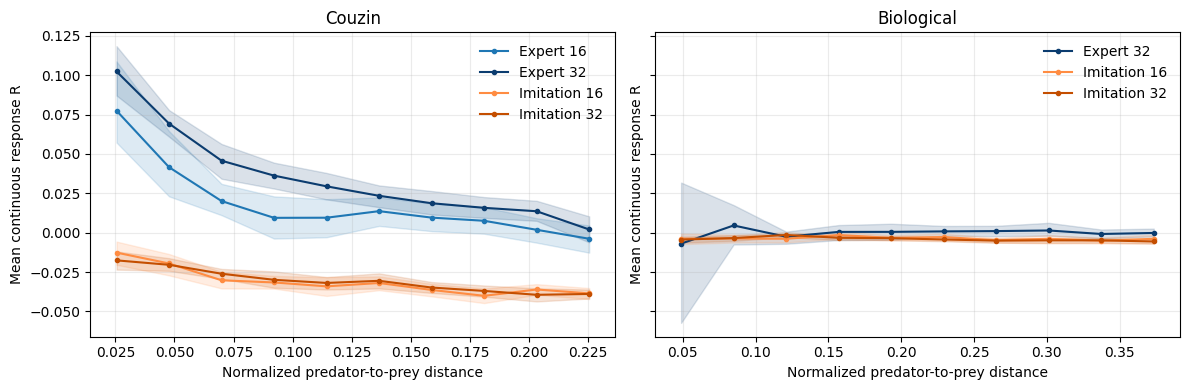

case,bin,distance,mean,ci_low,ci_high,n,clusters,supported
couzin_expert_16,0,0.025510767,0.077478372,0.057264637,0.10875652,1526,20,True
couzin_expert_16,1,0.047727697,0.041592661,0.023082869,0.064528391,3258,20,True
couzin_expert_16,2,0.06994462,0.020099642,0.011137893,0.031011555,5882,20,True
couzin_expert_16,3,0.092161551,0.0094446698,-0.0037242917,0.023055643,5950,20,True
couzin_expert_16,4,0.11437847,0.0095194504,-0.002868389,0.021275375,6860,20,True
couzin_expert_16,5,0.1365954,0.013692377,0.0043114978,0.022424124,7444,20,True
couzin_expert_16,6,0.15881231,0.0095876278,0.00099822204,0.018570883,8340,20,True
couzin_expert_16,7,0.18102926,0.007567443,-0.00063634745,0.016227163,9267,20,True
couzin_expert_16,8,0.20324618,0.0018540169,-0.006315269,0.0091975899,10199,20,True
couzin_expert_16,9,0.22546309,-0.0038404276,-0.012661329,0.0045811548,11135,20,True


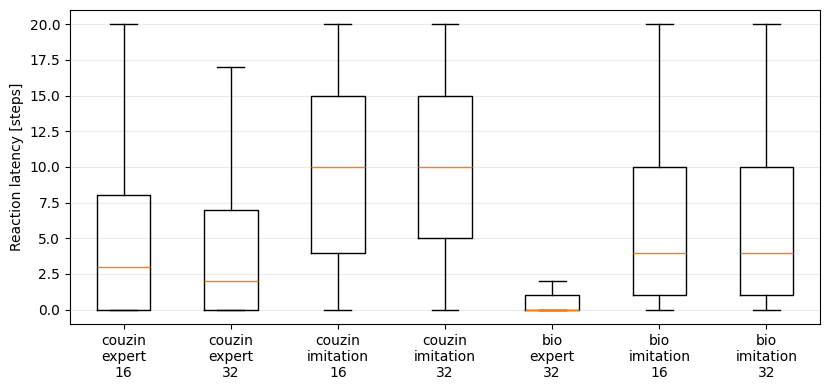

case,n,valid_clips,mean,std,median,q25,q75,min,max
couzin_expert_16,13974,20,4.6463432,5.3071012,3,0,8,0,20
couzin_expert_32,34704,20,4.2974873,4.9954243,2,0,7,0,20
couzin_imitation_16,289,20,9.9307957,6.0369725,10,4,15,0,20
couzin_imitation_32,347,20,10.020173,5.9364696,10,5,15,0,20
bio_expert_32,49,15,0.83673471,1.5165339,0,0,1,0,7
bio_imitation_16,5801,20,6.0677471,5.6895547,4,1,10,0,20
bio_imitation_32,15505,20,6.2069011,5.6586456,4,1,10,0,20


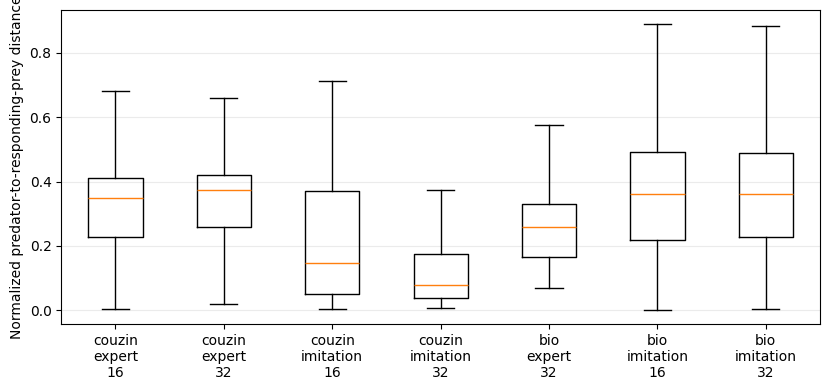

case,n,valid_clips,mean,std,median,q25,q75,min,max
couzin_expert_16,13974,20,0.32463509,0.13507946,0.34719056,0.22889194,0.41058284,0.00342202,0.86094236
couzin_expert_32,34704,20,0.34668854,0.13275152,0.37247527,0.25970283,0.41965419,0.0027084479,0.90517205
couzin_imitation_16,289,20,0.22254923,0.20303777,0.14719249,0.050589878,0.37188748,0.0036509067,0.71076316
couzin_imitation_32,347,20,0.12011368,0.11146383,0.07867042,0.037166398,0.17427123,0.0074501256,0.65258878
bio_expert_32,49,15,0.2616787,0.1173429,0.25870806,0.16491649,0.33134255,0.068761453,0.57451528
bio_imitation_16,5801,20,0.3610515,0.17855261,0.36087969,0.21968058,0.49234796,0.0020431012,0.88851058
bio_imitation_32,15505,20,0.36423695,0.17822064,0.35966992,0.22660798,0.48985294,0.0033928107,0.93109763


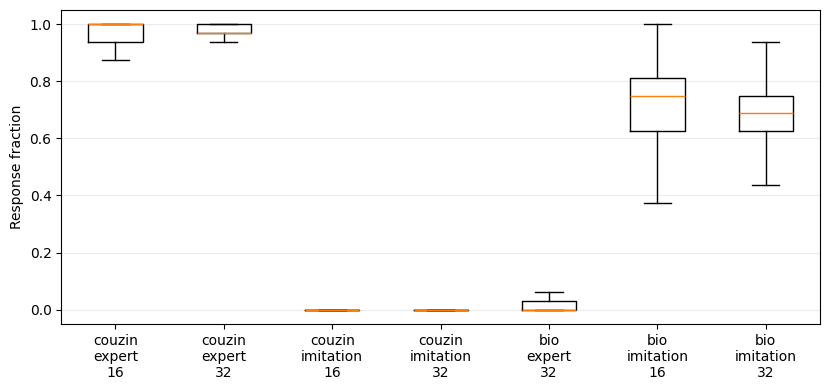

case,n,valid_clips,mean,std,median,q25,q75,min,max
couzin_expert_16,911,20,0.95869923,0.076873302,1,0.9375,1,0,1
couzin_expert_32,1117,20,0.97090423,0.056270294,0.96875,0.96875,1,0.09375,1
couzin_imitation_16,2685,20,0.0067271879,0.020465568,0,0,0,0,0.1875
couzin_imitation_32,3165,20,0.0034261453,0.01055335,0,0,0,0,0.0625
bio_expert_32,77,18,0.019886363,0.034124713,0,0,0.03125,0,0.15625
bio_imitation_16,502,20,0.72223604,0.1406959,0.75,0.625,0.8125,0,1
bio_imitation_32,719,20,0.67389601,0.13255559,0.6875,0.625,0.75,0.15625,0.96875


case,threshold,events,contributing_clips,mean_response_fraction,fraction_events_two_plus
couzin_expert_16,0.075,911,20,0.96425635,0.99780464
couzin_expert_16,0.1,911,20,0.95869923,0.99780464
couzin_expert_16,0.125,911,20,0.95115256,0.99780464
couzin_expert_32,0.075,1117,20,0.97543639,1
couzin_expert_32,0.1,1117,20,0.97090417,1
couzin_expert_32,0.125,1117,20,0.96681958,1
couzin_imitation_16,0.075,2685,20,0.096461825,0.46852887
couzin_imitation_16,0.1,2685,20,0.0067271879,0.0040968345
couzin_imitation_16,0.125,2685,20,0.0030726257,0.00074487895
couzin_imitation_32,0.075,3165,20,0.018167457,0.11658768


In [7]:
# Directional escape behavior and the continuous change in away-alignment.
plot_curve('escape_alignment','Mean escape alignment'); show_curve_values('escape_alignment')
plot_curve('continuous_predator_response_curve','Mean continuous response R','Normalized predator-to-prey distance'); show_curve_values('continuous_predator_response_curve')

# Event-level timing, spatial response point, and fraction of responding prey.
plot_scalar('reaction_latency','Reaction latency [steps]',event=True); show_distribution_values('reaction_latency',event=True)
plot_scalar('reaction_distance_norm','Normalized predator-to-responding-prey distance',event=True); show_distribution_values('reaction_distance_norm',event=True)
plot_scalar('response_fraction','Response fraction',event=True); show_distribution_values('response_fraction',event=True)

# Compact threshold-sensitivity summary; the primary threshold remains 0.10.
sensitivity_rows=[]
for case_name,thresholds in results['response_threshold_sensitivity'].items():
 for threshold,summary in thresholds.items():
  sensitivity_rows.append({'case':case_name,'threshold':threshold,'events':summary['events'],'contributing_clips':summary['contributing_clips'],'mean_response_fraction':float(summary['mean_response_fraction'].detach().cpu()),'fraction_events_two_plus':float(summary['fraction_events_two_plus'].detach().cpu())})
display_table(sensitivity_rows,'Response-threshold sensitivity')


# Collective Response Metrics

Event-relative NND reports the relative change from approach onset, while polarization reports the absolute change. DoS and DoA summarize all valid frames; cascade and propagation reuse the same individual first-response times, with propagation defined only when at least two prey respond.

The final table separates the 16-to-32 generalization shift from imitation fidelity at each group size.

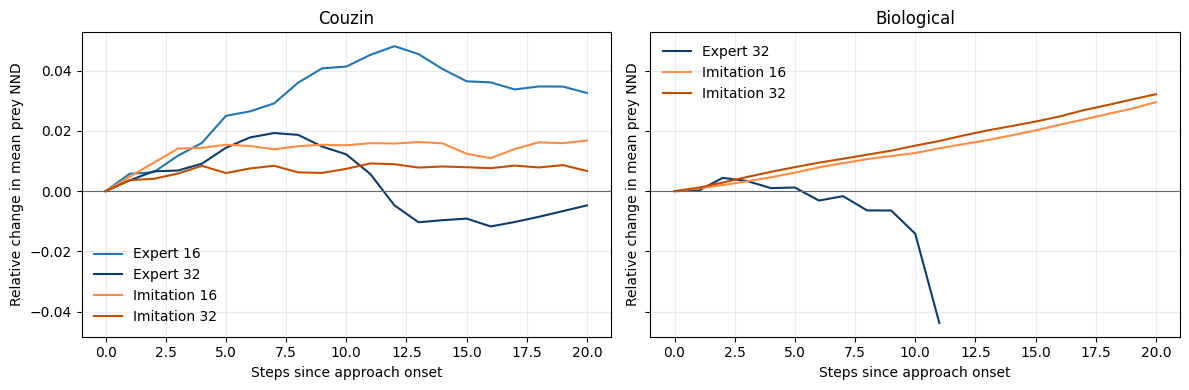

case,step,mean,std,n
couzin_expert_16,0,0,0,911
couzin_expert_16,1,0.0057640141,0.091597505,909
couzin_expert_16,2,0.0062835161,0.1356194,908
couzin_expert_16,3,0.01172658,0.17138514,906
couzin_expert_16,4,0.016000107,0.19539331,906
couzin_expert_16,5,0.02499588,0.22116165,906
couzin_expert_16,6,0.026484689,0.23857041,906
couzin_expert_16,7,0.029115772,0.25502634,905
couzin_expert_16,8,0.036015138,0.27117422,905
couzin_expert_16,9,0.040775832,0.28299704,905


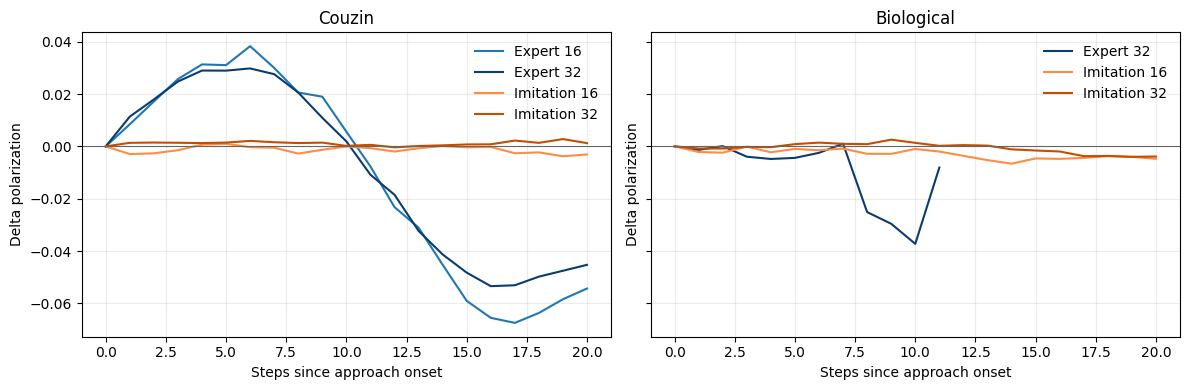

case,step,mean,std,n
couzin_expert_16,0,0,0,911
couzin_expert_16,1,0.0084384093,0.097617842,909
couzin_expert_16,2,0.017163122,0.13477047,908
couzin_expert_16,3,0.025697768,0.1651527,906
couzin_expert_16,4,0.031312671,0.19689199,906
couzin_expert_16,5,0.031038223,0.22587878,906
couzin_expert_16,6,0.038280368,0.24244271,906
couzin_expert_16,7,0.029981889,0.26269147,905
couzin_expert_16,8,0.020574767,0.27953815,905
couzin_expert_16,9,0.018980952,0.2861186,905


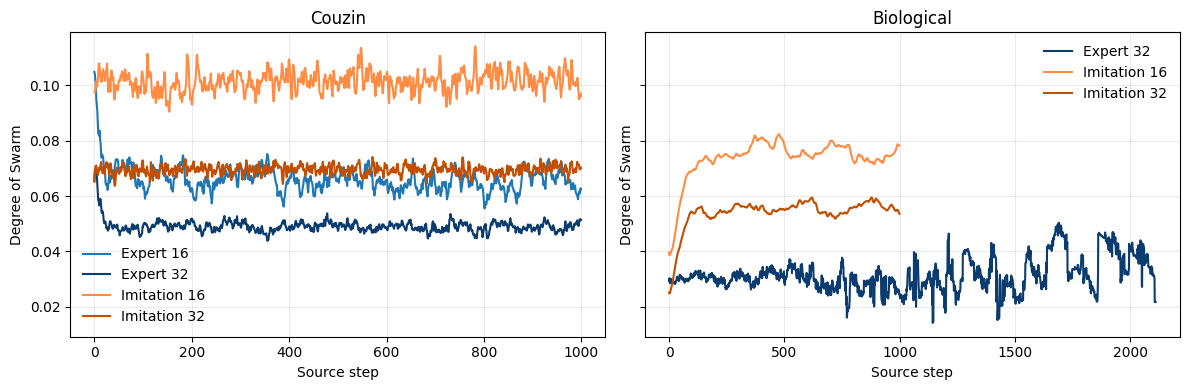

case,steps,clips,aggregate_mean,aggregate_std
couzin_expert_16,1000,20,0.066131771,0.0018181478
couzin_expert_32,1000,20,0.049122021,0.00075660471
couzin_imitation_16,1000,20,0.10143201,0.0015029828
couzin_imitation_32,1000,20,0.069513038,0.0005439191
bio_expert_32,2111,35,0.030262154,0.0055890167
bio_imitation_16,1000,20,0.073644996,0.0067479098
bio_imitation_32,1000,20,0.054073025,0.003345497


case,step,mean,clips
couzin_expert_16,0,0.10482363,20
couzin_expert_16,1,0.10411026,20
couzin_expert_16,2,0.10173303,20
couzin_expert_16,3,0.10001924,20
couzin_expert_16,4,0.094978109,20
couzin_expert_16,5,0.092812061,20
couzin_expert_16,6,0.090787917,20
couzin_expert_16,7,0.086984277,20
couzin_expert_16,8,0.082453534,20
couzin_expert_16,9,0.08228381,20


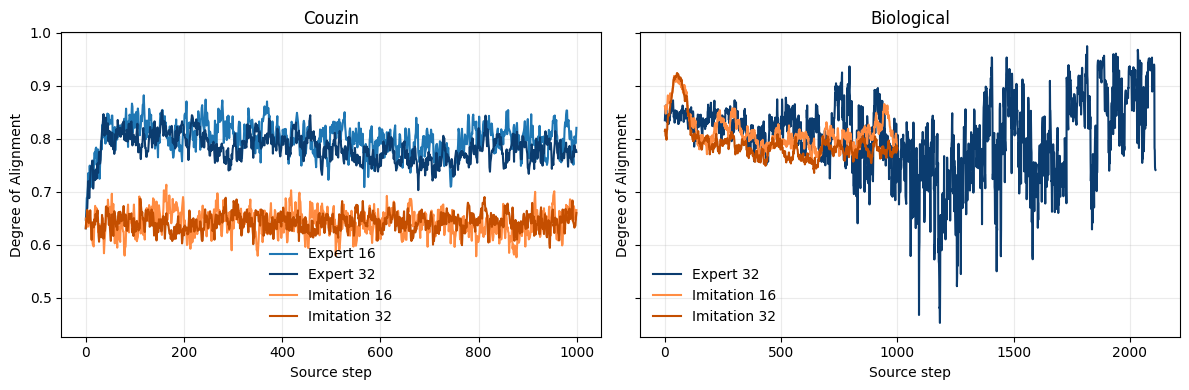

case,steps,clips,aggregate_mean,aggregate_std
couzin_expert_16,1000,20,0.80200231,0.024658429
couzin_expert_32,1000,20,0.78252614,0.030521536
couzin_imitation_16,1000,20,0.64173019,0.011254729
couzin_imitation_32,1000,20,0.64294392,0.0076697054
bio_expert_32,2111,35,0.8327865,0.055062301
bio_imitation_16,1000,20,0.81489992,0.014385505
bio_imitation_32,1000,20,0.79123002,0.021276096


case,step,mean,clips
couzin_expert_16,0,0.6470539,20
couzin_expert_16,1,0.65871304,20
couzin_expert_16,2,0.68853736,20
couzin_expert_16,3,0.68784273,20
couzin_expert_16,4,0.70857179,20
couzin_expert_16,5,0.73515666,20
couzin_expert_16,6,0.71105856,20
couzin_expert_16,7,0.72432894,20
couzin_expert_16,8,0.74927413,20
couzin_expert_16,9,0.72936523,20


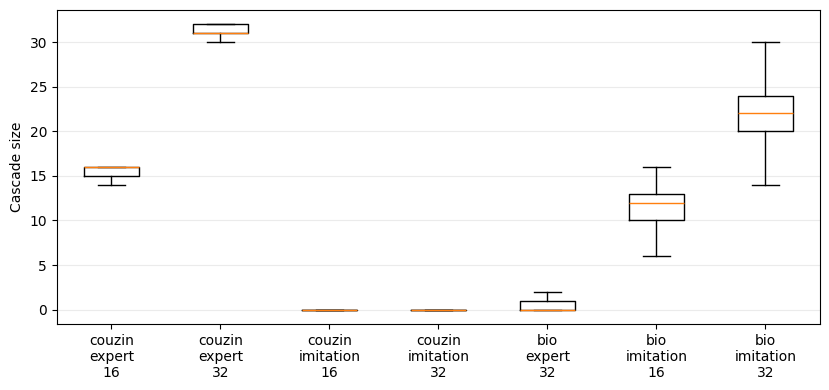

case,n,valid_clips,mean,std,median,q25,q75,min,max
couzin_expert_16,911,20,15.339188,1.2299728,16,15,16,0,16
couzin_expert_32,1117,20,31.068935,1.8006494,31,31,32,3,32
couzin_imitation_16,2685,20,0.10763501,0.32744908,0,0,0,0,3
couzin_imitation_32,3165,20,0.10963665,0.33770719,0,0,0,0,2
bio_expert_32,77,18,0.63636363,1.0919908,0,0,1,0,5
bio_imitation_16,502,20,11.555777,2.2511344,12,10,13,0,16
bio_imitation_32,719,20,21.564672,4.2417789,22,20,24,5,31


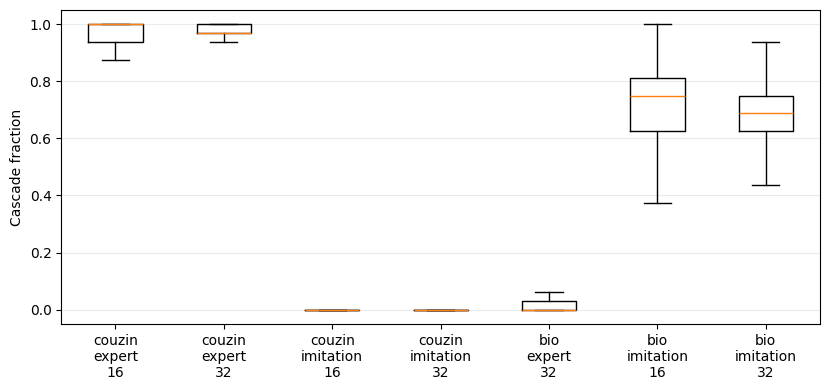

case,n,valid_clips,mean,std,median,q25,q75,min,max
couzin_expert_16,911,20,0.95869923,0.076873302,1,0.9375,1,0,1
couzin_expert_32,1117,20,0.97090423,0.056270294,0.96875,0.96875,1,0.09375,1
couzin_imitation_16,2685,20,0.0067271879,0.020465568,0,0,0,0,0.1875
couzin_imitation_32,3165,20,0.0034261453,0.01055335,0,0,0,0,0.0625
bio_expert_32,77,18,0.019886363,0.034124713,0,0,0.03125,0,0.15625
bio_imitation_16,502,20,0.72223604,0.1406959,0.75,0.625,0.8125,0,1
bio_imitation_32,719,20,0.67389601,0.13255559,0.6875,0.625,0.75,0.15625,0.96875


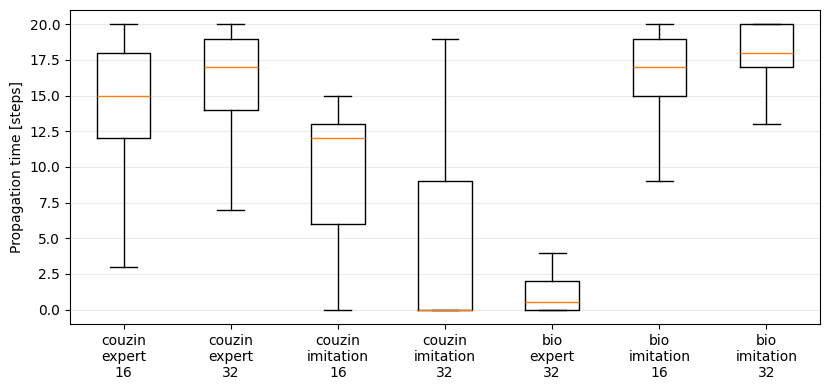

case,n,valid_clips,mean,std,median,q25,q75,min,max
couzin_expert_16,909,20,14.654566,4.0899582,15,12,18,0,20
couzin_expert_32,1117,20,15.918531,3.4977403,17,14,19,0,20
couzin_imitation_16,11,5,8.818182,5.2365532,12,6,13,0,15
couzin_imitation_32,26,8,4.0769229,6.4743462,0,0,9,0,19
bio_expert_32,14,12,1.4285715,1.9897697,0,0,2,0,7
bio_imitation_16,501,20,16.449102,3.2775631,17,15,19,0,20
bio_imitation_32,719,20,17.721836,2.5410037,18,17,20,1,20


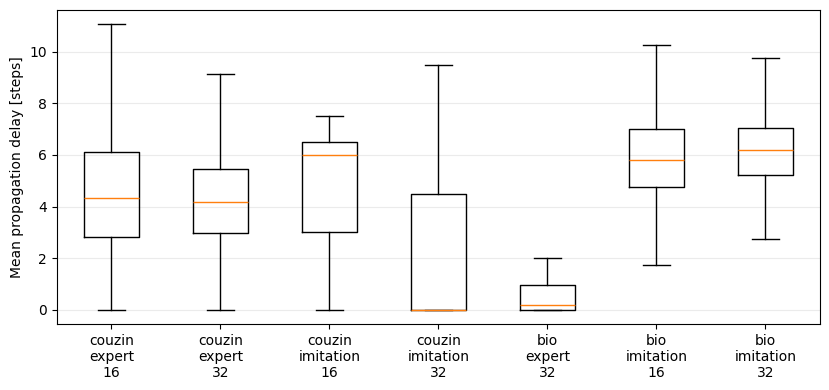

case,n,valid_clips,mean,std,median,q25,q75,min,max
couzin_expert_16,909,20,4.6203771,2.3205912,4.3333335,2.8,6.125,0,11.928572
couzin_expert_32,1117,20,4.3053598,1.7930413,4.1875,2.96875,5.4375,0,10.666667
couzin_imitation_16,11,5,4.409091,2.6182766,6,3,6.5,0,7.5
couzin_imitation_32,26,8,2.0384614,3.2371731,0,0,4.5,0,9.5
bio_expert_32,14,12,0.63452381,0.86093491,0,0,0.9375,0,2.8
bio_imitation_16,501,20,5.8891993,1.6911179,5.818182,4.7692308,7,0,11.307693
bio_imitation_32,719,20,6.1735058,1.3989463,6.1904764,5.2173915,7.0377493,0.80000001,12.1875


case,valid_propagation_events,total_approach_events,fraction_valid
couzin_expert_16,909,911,0.99780461
couzin_expert_32,1117,1117,1
couzin_imitation_16,11,2685,0.0040968343
couzin_imitation_32,26,3165,0.0082148499
bio_expert_32,14,77,0.18181818
bio_imitation_16,501,502,0.99800797
bio_imitation_32,719,719,1


In [8]:
# Approach-relative changes in density and global alignment.
plot_event('nnd_during_approach','Relative change in mean prey NND'); show_event_profile_values('nnd_during_approach')
plot_event('polarization_during_approach','Delta polarization'); show_event_profile_values('polarization_during_approach')

# Whole-sequence local density and nearest-neighbor alignment.
plot_timeline('dos_timeline','Degree of Swarm'); show_timeline_values('dos_timeline','dos')
plot_timeline('doa_timeline','Degree of Alignment'); show_timeline_values('doa_timeline','doa')

# Event-level response spread and temporal propagation through the swarm.
plot_scalar('cascade_size','Cascade size',event=True); show_distribution_values('cascade_size',event=True)
plot_scalar('cascade_fraction','Cascade fraction',event=True); show_distribution_values('cascade_fraction',event=True)
plot_scalar('propagation_time','Propagation time [steps]',event=True); show_distribution_values('propagation_time',event=True)
plot_scalar('mean_propagation_delay','Mean propagation delay [steps]',event=True); show_distribution_values('mean_propagation_delay',event=True)
propagation_rows=[{'case':name,'valid_propagation_events':r['diagnostics']['valid_propagation_events'],'total_approach_events':r['diagnostics']['total_approach_events'],'fraction_valid':r['diagnostics']['fraction_valid_propagation_events']} for name,r in case_results.items()]
display_table(propagation_rows,'Propagation support (at least two responders)')


In [9]:
# Flatten scalar and curve-based group-size results into one readable table.
group_size_summary,group_size_table_rows={},[]
for source,metrics in group_size_results.items():
 group_size_summary[source]={}
 for metric,value in metrics.items():
  item={k:value[k].detach().cpu() for k in ('delta_expert','delta_imitation','generalization_error','valid','fidelity_error_16','fidelity_error_32','valid_fidelity_16','valid_fidelity_32')}; item['MAGE']=float(value['mage'].detach().cpu()); item['MAFE_16']=float(value['mean_absolute_fidelity_error_16'].detach().cpu()); item['MAFE_32']=float(value['mean_absolute_fidelity_error_32'].detach().cpu()); group_size_summary[source][metric]=item
  de,di,ge=item['delta_expert'].flatten(),item['delta_imitation'].flatten(),item['generalization_error'].flatten()
  valid=item['valid'].flatten(); f16=item['fidelity_error_16'].flatten(); f32=item['fidelity_error_32'].flatten(); vf16=item['valid_fidelity_16'].flatten(); vf32=item['valid_fidelity_32'].flatten()
  for i in range(len(ge)):
   group_size_table_rows.append({'source':source,'metric':metric,'bin':'aggregate' if len(ge)==1 else i,'delta_expert':de[i].item(),'delta_imitation':di[i].item(),'generalization_error':ge[i].item(),'valid_generalization':bool(valid[i]),'fidelity_error_16':f16[i].item(),'valid_fidelity_16':bool(vf16[i]),'fidelity_error_32':f32[i].item(),'valid_fidelity_32':bool(vf32[i]),'MAGE':item['MAGE'],'MAFE_16':item['MAFE_16'],'MAFE_32':item['MAFE_32']})

# Retain the tensor form and display the presentation-oriented rows separately.
numerical_outputs['group_size']=group_size_summary
display_table(group_size_table_rows,'Group-size generalization shift and imitation fidelity')


source,metric,bin,delta_expert,delta_imitation,generalization_error,valid_generalization,fidelity_error_16,valid_fidelity_16,fidelity_error_32,valid_fidelity_32,MAGE,MAFE_16,MAFE_32
couzin,propagation_time,aggregate,1.2880507,-2.9833341,-4.2713847,True,5.2789068,True,9.5502911,True,4.2713847,5.2789068,9.5502911
couzin,nnd_during_approach,aggregate,-0.037065446,-0.0099765081,0.027088938,True,0.011445915,True,0.015643023,True,0.027088938,0.011445915,0.015643023
couzin,polarization_during_approach,aggregate,0.0031408221,0.0043232692,0.0011824472,True,0.046194702,True,0.047377151,True,0.0011824472,0.046194702,0.047377151
couzin,cascade_size,aggregate,15.725658,0.0025933981,-15.723065,True,15.246073,True,30.969139,True,15.723065,15.246073,30.969139
couzin,escape_alignment,aggregate,-0.0043232739,0.0017357953,0.0060590692,True,0.26751676,True,0.26145771,True,0.0060590692,0.26751676,0.26145771
couzin,reaction_distance,aggregate,1.6238518,-7.0569811,-8.6808329,True,7.4458752,True,16.126709,True,8.6808329,7.4458752,16.126709
couzin,doa,aggregate,-0.019476235,0.0012136102,0.020689845,True,0.16027212,True,0.13958228,True,0.020689845,0.16027212,0.13958228
couzin,continuous_predator_response,aggregate,-0.0011345297,-0.0007577911,0.00037673861,True,0.034240272,True,0.033863533,True,0.00037673861,0.034240272,0.033863533
couzin,reaction_latency,aggregate,-0.34531164,0.0048856735,0.35019732,True,5.3212533,True,5.6714506,True,0.35019732,5.3212533,5.6714506
couzin,response_fraction,aggregate,0.011635423,-0.0032705732,-0.014905996,True,0.95287955,True,0.9677856,True,0.014905996,0.95287955,0.9677856


# Video Time-Step Grid

This independent visualization helper extracts six requested frames from a source video. It does not participate in metric calculation and can be rerun without recomputing the analysis results.

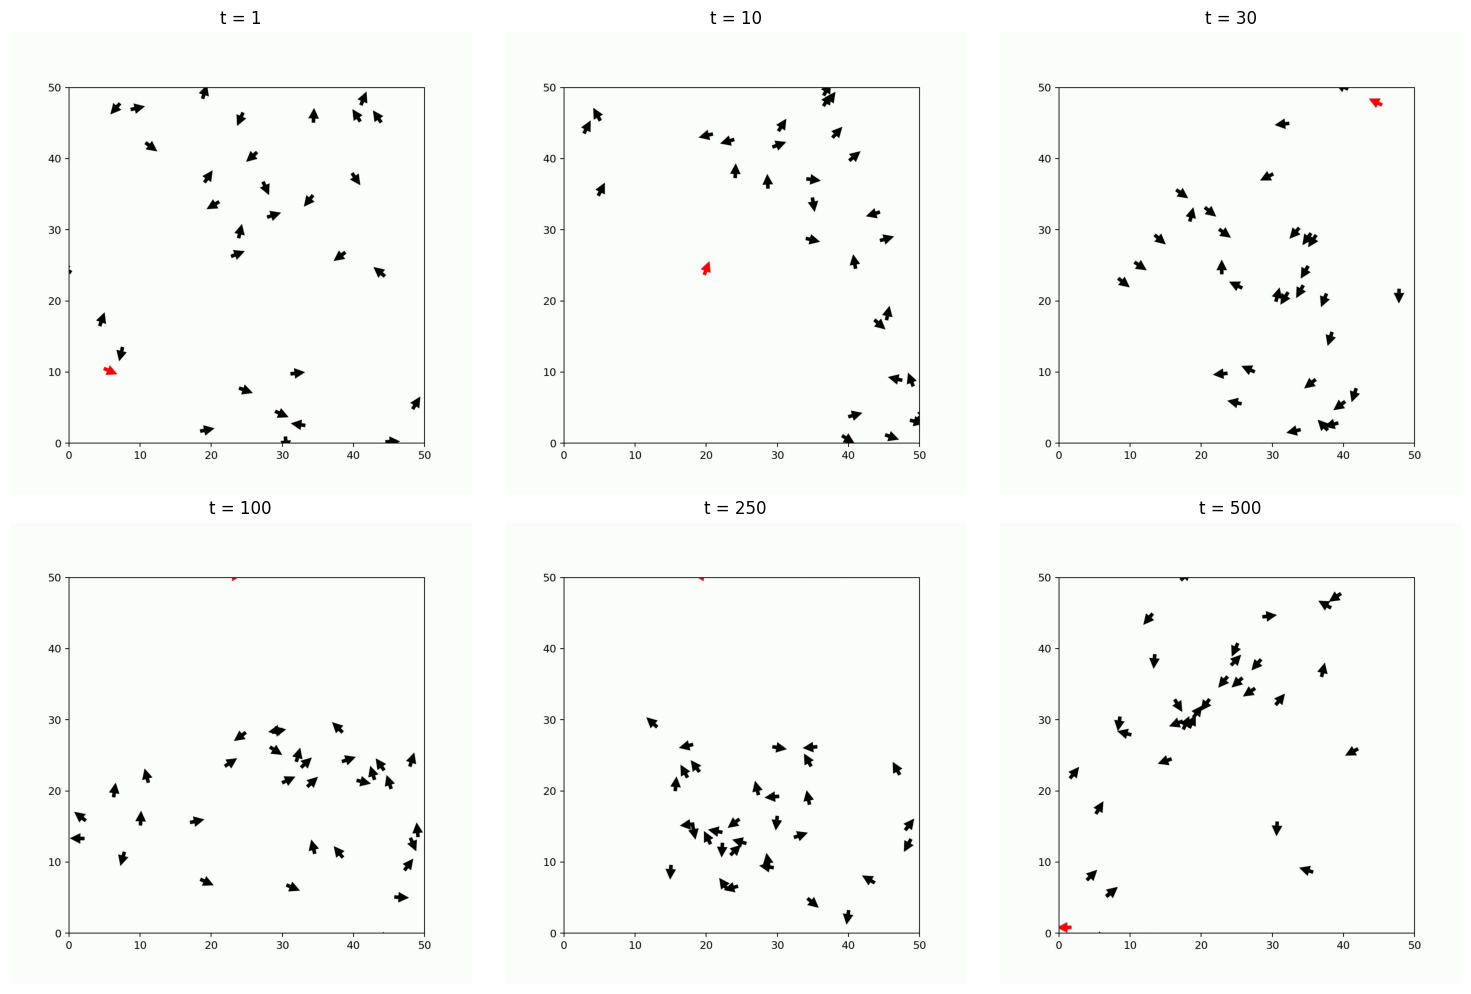

In [10]:
# Read and arrange six requested source frames without loading the full video.
def plot_video_timesteps(video_path,timesteps,*,title='',figsize=(15,10),clip_out_of_range=True):
 import cv2
 video_path=Path(video_path).resolve(); timesteps=list(timesteps)
 if len(timesteps)!=6: raise ValueError('Exactly six timesteps are required')
 cap=cv2.VideoCapture(str(video_path))
 if not cap.isOpened(): raise RuntimeError(f'Could not open {video_path}')
 count=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); requested=np.asarray(timesteps,dtype=int)
 if (requested>=count).any() and not clip_out_of_range: cap.release(); raise IndexError('Timestep exceeds video length')
 frames=np.clip(requested,0,count-1); fig,axes=plt.subplots(2,3,figsize=figsize)

 # Seek directly to each frame and release the video handle even if reading fails.
 try:
  for ax,t,frame in zip(axes.flat,requested,frames):
   cap.set(cv2.CAP_PROP_POS_FRAMES,int(frame)); ok,image=cap.read()
   if not ok: raise RuntimeError(f'Could not read frame {frame}')
   ax.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB)); ax.set_title(f't = {t}'); ax.axis('off')
 finally: cap.release()
 if title: fig.suptitle(title)
 fig.tight_layout(); return fig,axes

# Example grid used in the paper-analysis workflow.
VIDEO_PATH=PROJECT_ROOT/'ICRA2027-PredatorPreyGAIL/assets/videos/couzin.mp4'
video_grid_fig,video_grid_axes=plot_video_timesteps(VIDEO_PATH,[1,10,30,100,250,500]); plt.show()


# Analysis of Modular Networks — Biological vs Couzin Policies

This reuses Jannik's Pairwise-Interaction/Attention analysis without modifying his repository.

## Analysis setup

The current checkpoints include an additional active-mask feature, which is appended automatically. Each map is evaluated on the same relative-position grid and averaged over uniformly sampled relative-velocity orientations. This keeps the Biological and Couzin results directly comparable.

## Visual interpretation

The Pairwise-Interaction maps show the directional action produced for a neighbor at each relative position. The Attention maps show which relative positions receive stronger or weaker attention.

The original `inferno` (PIN) and `RdBu` (attention) color schemes are retained. Shared color scales are used across both policies so visual differences reflect model differences rather than separate rescaling. The focal agent is shown at the origin in every map: a predator icon for predator maps and a prey icon for prey and preyâ€“predator maps.

In [11]:
from matplotlib import colors
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Resolution and batching follow the original map construction while keeping GPU memory bounded.
MODULAR_GRID_SIZE, MODULAR_ORIENTATIONS, MODULAR_BATCH_SIZE = 100, 100, 65536

# Load independent policy pairs for the Couzin-trained and biologically trained models.
modular_policy_pairs = {
 'Couzin': pa.load_policy_pair(COUZIN_POLICY, COUZIN_POLICY['root']),
 'Biological': pa.load_policy_pair(BIO_POLICY, BIO_POLICY['root']),
}

# Prepare one result slot and one task for every policy/interaction perspective.
modular_network_results = {name:{} for name in modular_policy_pairs}
modular_tasks = [(name,role) for name in modular_policy_pairs for role in ('predator','prey','prey_pred')]

# Compute all maps once; predator and prey policies are selected according to the role.
for policy_name,role in tqdm(modular_tasks,desc='Computing modular-network maps'):
 prey_policy,predator_policy = modular_policy_pairs[policy_name]
 policy = predator_policy if role == 'predator' else prey_policy
 modular_network_results[policy_name][role] = pa.compute_modular_network_maps(
  policy,role=role,grid_size=MODULAR_GRID_SIZE,n_orientations=MODULAR_ORIENTATIONS,
  batch_size=MODULAR_BATCH_SIZE,device=DEVICE)


Computing modular-network maps: 100%|██████████| 6/6 [00:00<00:00, 11.35it/s]


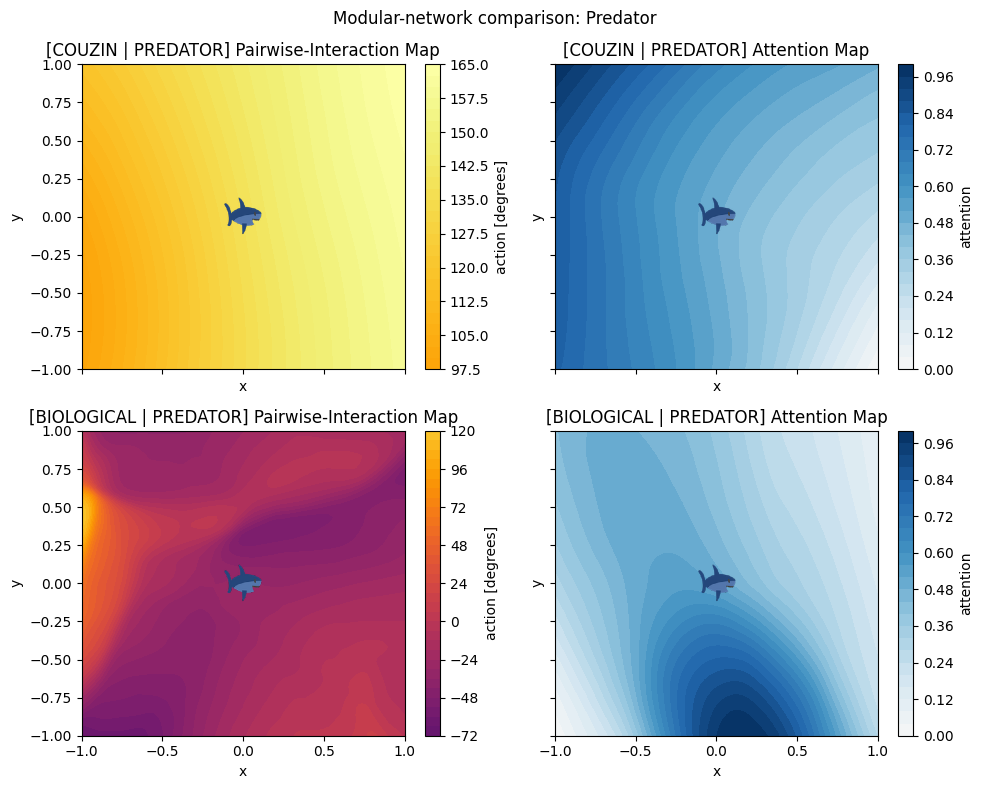

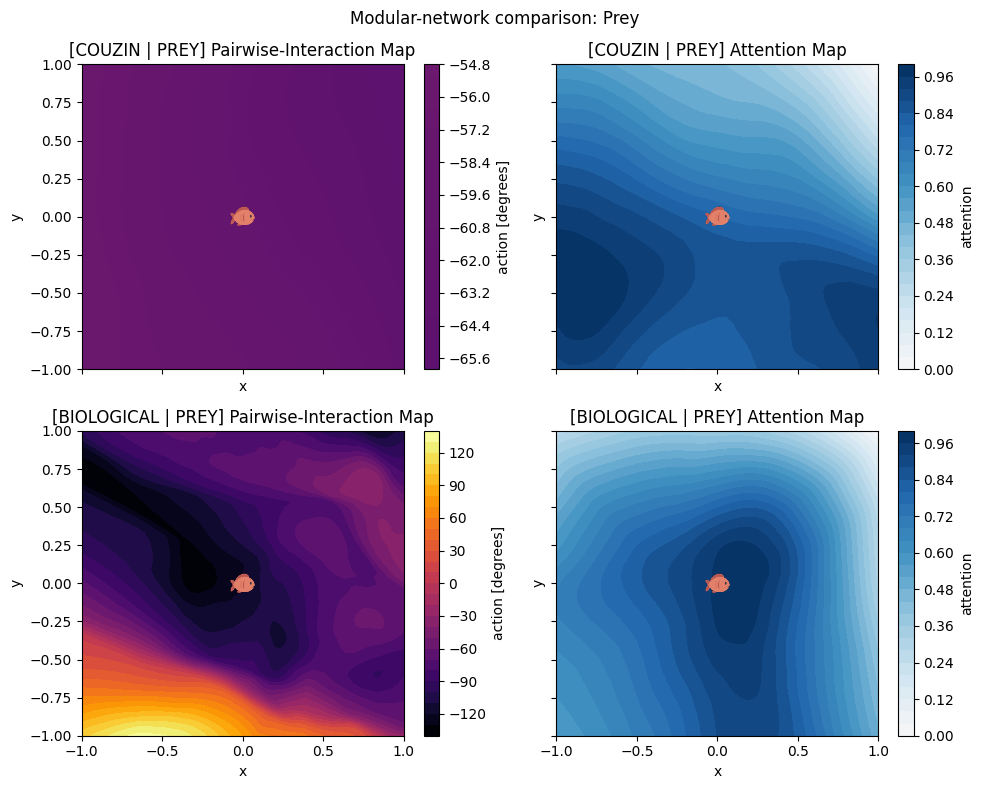

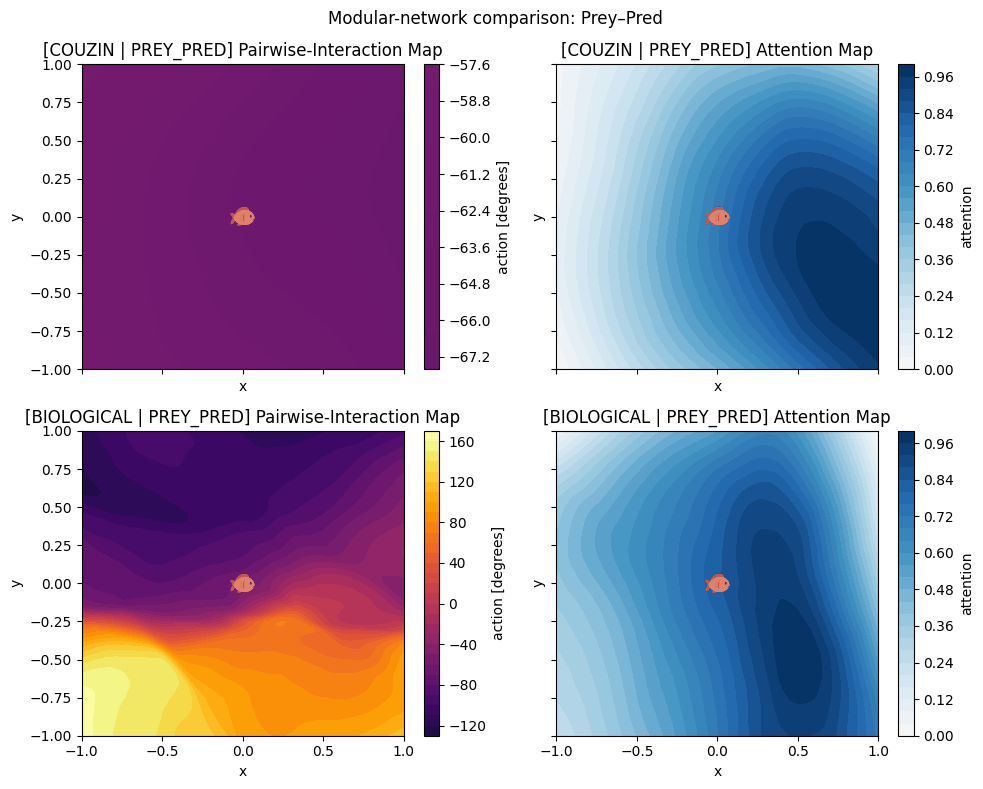

role,module,couzin_mean,biological_mean,mean_difference,MAE,RMSE,max_abs_difference,correlation
predator,Pairwise interaction,136.06883,-18.052977,-154.12183,154.15097,157.56104,215.90279,-0.1937017
predator,Attention,0.53849471,0.43843883,-0.10005593,0.23859817,0.28841427,0.81113774,0.021077471
prey,Pairwise interaction,-60.220207,-61.703457,-1.4832559,42.175598,57.172699,190.3203,0.23196049
prey,Attention,0.73429734,0.68791956,-0.04637783,0.14987871,0.18531665,0.53191161,0.59202403
prey_pred,Pairwise interaction,-62.893394,-12.384338,50.509052,78.791054,102.28627,226.03267,0.022071593
prey_pred,Attention,0.55714118,0.64078838,0.083647177,0.18097854,0.20716955,0.58667529,0.7473821


In [12]:
# Agent icons mirror the visual convention used in Jannik's experiment plots.
MODULAR_ICON_PATHS = {
 'predator': ANALYSIS_DIR/'images/predator.png',
 'prey': ANALYSIS_DIR/'images/prey.png',
 'prey_pred': ANALYSIS_DIR/'images/prey.png',
}

# Plot Couzin and Biological maps with a shared scale for one interaction perspective.
def plot_modular_network_comparison(role):
 policy_order=('Couzin','Biological'); action_maps=[modular_network_results[p][role]['action']*180 for p in policy_order]; attention_maps=[modular_network_results[p][role]['attention'] for p in policy_order]
 icon=plt.imread(MODULAR_ICON_PATHS[role])

 # Shared limits prevent policy-specific color normalization from hiding differences.
 vmax_action=max(float(m.abs().max()) for m in action_maps) or 1.0; vmax_attention=max(float(m.abs().max()) for m in attention_maps) or 1.0
 action_norm=colors.TwoSlopeNorm(vcenter=0,vmin=-vmax_action,vmax=vmax_action); attention_norm=colors.TwoSlopeNorm(vcenter=0,vmin=-vmax_attention,vmax=vmax_attention)

 # Couzin occupies the first row and Biological the second; modules form the columns.
 fig,axes=plt.subplots(2,2,figsize=(10,8),sharex=True,sharey=True)
 for row,policy_name in enumerate(policy_order):
  result=modular_network_results[policy_name][role]; x,y=np.meshgrid(result['x'].numpy(),result['y'].numpy())
  im_action=axes[row,0].contourf(x,y,action_maps[row].numpy(),levels=30,cmap='inferno',norm=action_norm)
  im_attention=axes[row,1].contourf(x,y,attention_maps[row].numpy(),levels=30,cmap='RdBu',norm=attention_norm)
  axes[row,0].set_title(f'[{policy_name.upper()} | {role.upper()}] Pairwise-Interaction Map'); axes[row,1].set_title(f'[{policy_name.upper()} | {role.upper()}] Attention Map')
  for ax in axes[row]:
   ax.set(xlabel='x',ylabel='y',xlim=(result['x'].min(),result['x'].max()),ylim=(result['y'].min(),result['y'].max()))
   ax.add_artist(AnnotationBbox(OffsetImage(icon,zoom=.45),(0,0),frameon=False,xycoords='data',zorder=5))
  fig.colorbar(im_action,ax=axes[row,0],label='action [degrees]'); fig.colorbar(im_attention,ax=axes[row,1],label='attention')
 fig.suptitle(f'Modular-network comparison: {role.replace("_","–").title()}'); fig.tight_layout(); plt.show(); return fig

# Generate one figure for Predator, Prey–Prey, and Prey–Predator interactions.
modular_network_figures = {role:plot_modular_network_comparison(role) for role in ('predator','prey','prey_pred')}

# Complement the visual maps with direct numerical differences between both policy families.
comparison_rows=[]; modular_network_comparison={}
for role in ('predator','prey','prey_pred'):
 modular_network_comparison[role]={}
 for module,key,scale in (('Pairwise interaction','action',180.0),('Attention','attention',1.0)):
  couzin=modular_network_results['Couzin'][role][key].float().flatten()*scale; biological=modular_network_results['Biological'][role][key].float().flatten()*scale; difference=biological-couzin
  correlation=float(torch.corrcoef(torch.stack((couzin,biological)))[0,1]) if couzin.std()>0 and biological.std()>0 else np.nan
  values={'couzin_mean':float(couzin.mean()),'biological_mean':float(biological.mean()),'mean_difference':float(difference.mean()),'MAE':float(difference.abs().mean()),'RMSE':float(difference.square().mean().sqrt()),'max_abs_difference':float(difference.abs().max()),'correlation':correlation}
  modular_network_comparison[role][key]=values; comparison_rows.append({'role':role,'module':module,**values})

# Retain maps and summaries for later figures, tables, or optional serialization.
results['modular_networks']=modular_network_results; numerical_outputs['modular_network_comparison']=modular_network_comparison
display_table(comparison_rows,'Biological versus Couzin modular-network comparison')
if SAVE_RESULTS: torch.save(results,OUTPUT_DIR/'predator_prey_metrics.pt')
